# Project 1

- Bioresponse dataset: https://api.openml.org/d/4134

Link google drive if in colab:

In [3]:
try:
  import google.colab
  colab = True
except:
  colab = False

if colab:
  from google.colab import drive
  drive.mount('/content/drive')

## Data analysis

Load and display first few rows

In [4]:
import pandas as pd
import numpy as np

if colab:
  path = '/content/drive/MyDrive/Colab Notebooks/bioresponse.csv'
else:
  path = 'data/bioresponse.csv'

df = pd.read_csv(path)
df.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776,target
0,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,0.243144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,0.106480,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1
2,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,0.352308,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,0.208989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,0.125177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


> This dataset predicts a biological response of molecules from their chemical properties. The columns D1-D1776 represent those molecules
    the target shows, whether the molecule was seen to evoke this response (1) or not (0)

Describe data to see what we work with

In [5]:
df.describe()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776,target
count,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,...,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000,3751.000000
mean,0.076948,0.592436,0.068142,0.038990,0.212112,0.686653,0.274713,0.455133,0.749517,0.270411,...,0.014663,0.013863,0.021861,0.015196,0.016796,0.012263,0.011730,0.020261,0.011197,0.542255
std,0.079989,0.105860,0.078414,0.115885,0.102592,0.078702,0.090017,0.162731,0.071702,0.096128,...,0.120215,0.116938,0.146249,0.122348,0.128522,0.110074,0.107683,0.140911,0.105236,0.498278
min,0.000000,0.282128,0.000000,0.000000,0.002630,0.137873,0.006130,0.000000,0.275590,0.003040,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.033300,0.517811,0.000000,0.000000,0.138118,0.625627,0.207374,0.378062,0.707339,0.194357,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.066700,0.585989,0.050000,0.000000,0.190926,0.674037,0.277845,0.499942,0.738961,0.284316,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.100000,0.668395,0.100000,0.000000,0.261726,0.740663,0.335816,0.569962,0.788177,0.344626,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,0.964381,0.950000,1.000000,1.000000,0.994735,0.790831,0.989870,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# data types
print("\nData types:\n", df.dtypes)

# number of rows and columns
print("\nShape:", df.shape)

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Distribution of the target variable
print("\nTarget distribution:")
print(df['target'].value_counts())


Data types:
 D1        float64
D2        float64
D3        float64
D4        float64
D5        float64
           ...   
D1773     float64
D1774     float64
D1775     float64
D1776     float64
target      int64
Length: 1777, dtype: object

Shape: (3751, 1777)
Missing values per column:
D1        0
D2        0
D3        0
D4        0
D5        0
         ..
D1773     0
D1774     0
D1775     0
D1776     0
target    0
Length: 1777, dtype: int64

Number of duplicate rows: 0

Target distribution:
target
1    2034
0    1717
Name: count, dtype: int64


Check if normalization is needed

In [7]:
# Find the global extrema
print("smallest value:", df.min().min())
print("highest value:", df.max().max())

smallest value: 0.0
highest value: 1.0


> All feature values are between 0 and 1, meaning the dataset is already normalized. No need to delete outliers. No further normalization is required

Check data distributions

In [8]:
from scipy.stats import normaltest

normal_count = 0
non_normal_count = 0

for col in df.select_dtypes(include=[np.number]).columns:
    stat, p = normaltest(df[col].dropna())
    if p > 0.05:
        normal_count += 1
    else:
        non_normal_count += 1

print(f"Normaly distributed features: {normal_count}")
print(f"Non-normaly distributed features: {non_normal_count}")


Normaly distributed features: 0
Non-normaly distributed features: 1777


> since the goal of this project is binary classification, the lack of normal distribution is not a problem

Remove corelated features (above 0.9)

In [9]:
corr_matrix = df.corr(numeric_only=True).abs()

# Remove very correlated features (abocve 0.9)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_reduced = df.drop(columns=to_drop)

df_reduced.shape

(3751, 1751)

Compute mutual information - nonlinear dependency metric (how data corelate with target)

In [10]:
from sklearn.feature_selection import mutual_info_classif

X = df_reduced.drop(columns=['target'])
y = df_reduced['target']

mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_series.head(20)) # how strong is the dependency of features to target


D15     0.119452
D27     0.117157
D19     0.094234
D66     0.090181
D95     0.089007
D74     0.079521
D69     0.078623
D56     0.075226
D32     0.074807
D14     0.074637
D54     0.071111
D64     0.070698
D2      0.070100
D75     0.068754
D61     0.067210
D48     0.064880
D84     0.063907
D67     0.062904
D107    0.062607
D10     0.062399
dtype: float64


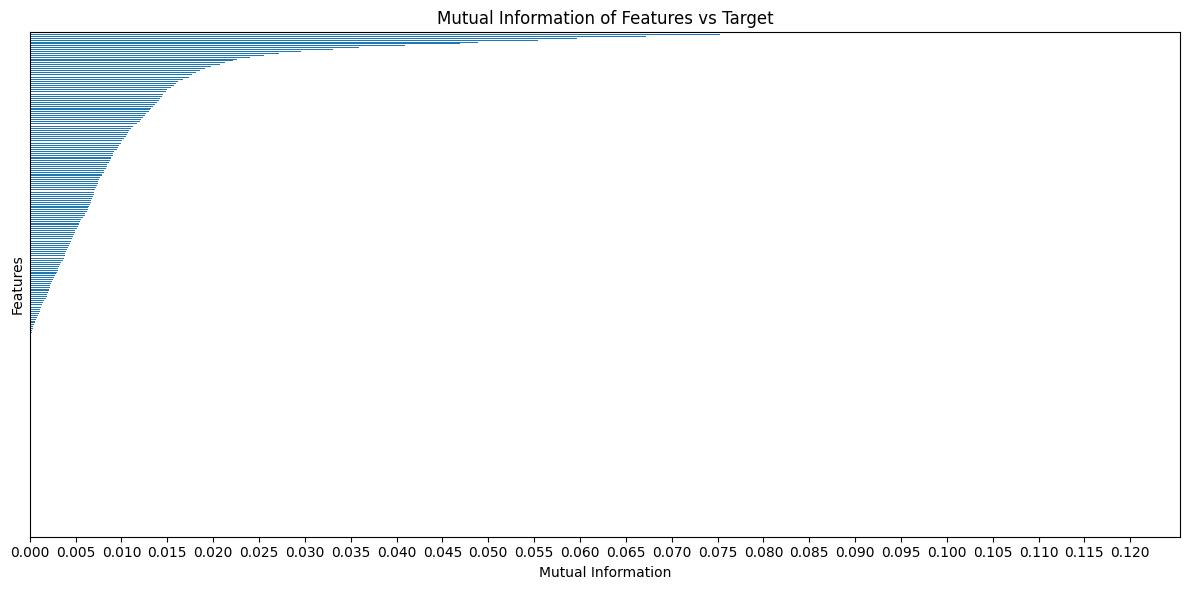

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
mi_series.sort_values(ascending=True).plot(kind='barh')
plt.title('Mutual Information of Features vs Target')
plt.xlabel('Mutual Information')
plt.ylabel('Features')
plt.yticks([])
plt.xticks(np.arange(0, mi_series.max() + 0.005, 0.005))

plt.tight_layout()
plt.show()


In [12]:
threshold = 0.05 # if the MI is less then then treshold, count it as noise
to_drop = mi_series[mi_series < threshold].index
df_filtered = df_reduced.drop(columns=to_drop)

df_filtered.shape

print(f"Keeping {df_filtered.shape[1]} features from original {df_reduced.shape[1]}")

df_filtered.to_csv('data/bioresponse_filtered.csv', index=True)
print("Filtered dataset saved to 'data/bioresponse_filtered.csv'")


Keeping 33 features from original 1751
Filtered dataset saved to 'data/bioresponse_filtered.csv'
